In [4]:
import numpy as np
from sklearn.impute import KNNImputer
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score
from scipy.optimize import linear_sum_assignment

from utils import plot_dec_performance_average
from utils import load_penguins
from utils import TabularMissingness
from utils.imputer import MeanTabularImputer
from models.gmm import GMMMissing
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
import numpy as np
from sklearn.mixture import GaussianMixture
from sklearn.metrics.cluster import contingency_matrix
from scipy.optimize import linear_sum_assignment
from utils import clustering_accuracy
from utils import MeanTabularImputer, MedianTabularImputer, KNNTabularImputer

In [18]:
missingness = TabularMissingness()
mean_imputer = MeanTabularImputer()
knn_imputer = KNNTabularImputer()

missingness_percentages = np.arange(0, 100, 5) / 100

n_runs = 100

# Loading Data

In [6]:
X, y, classes = load_penguins(return_numpy=True, encode_labels=True)
n_classes = len(classes)

In [8]:
def run_simulation(frac_list, X, y, n_classes):
    run_ari, run_nmi, run_acc = [], [], []

    for frac in frac_list:
        missing_data = missingness.apply_stratified(
            X, y,
            method="mar",
            frac=frac,
            dep_col=0,
            miss_col=1,
        )

        x_filled = mean_imputer.impute(missing_data)

        gmm = GaussianMixture(n_components=n_classes)
        y_pred = gmm.fit_predict(x_filled)

        run_ari.append(adjusted_rand_score(y, y_pred))
        run_nmi.append(normalized_mutual_info_score(y, y_pred))
        run_acc.append(clustering_accuracy(y, y_pred))

    return run_ari, run_nmi, run_acc


results = Parallel(n_jobs=-1, backend="loky")(
    delayed(run_simulation)(missingness_percentages, X, y, n_classes)
    for _ in range(n_runs)
)

ari_runs = [r[0] for r in results]
nmi_runs = [r[1] for r in results]
acc_runs = [r[2] for r in results]

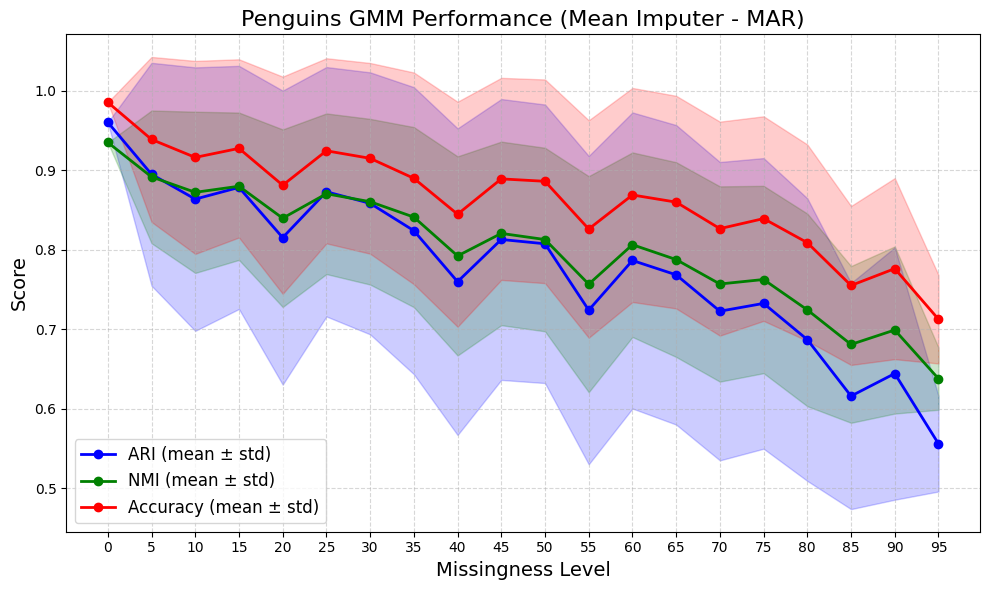

In [11]:
plot_dec_performance_average(
    missingness_percentages=missingness_percentages * 100,
    score_arrays=[ari_runs, nmi_runs, acc_runs],
    labels=['ARI', 'NMI', 'Accuracy'],
    title='Penguins GMM Performance (Mean Imputer - MAR)'
)

In [10]:
def run_simulation(frac_list, X, y, n_classes):
    run_ari, run_nmi, run_acc = [], [], []

    for frac in frac_list:
        missing_data = missingness.apply_stratified(
            X, y,
            method="mar",
            frac=frac,
            dep_col=0,
            miss_col=1,
        )

        gmm = GMMMissing(n_components=n_classes)
        gmm.fit(missing_data)

        y_pred = gmm.predict(missing_data)

        run_ari.append(adjusted_rand_score(y, y_pred))
        run_nmi.append(normalized_mutual_info_score(y, y_pred))
        run_acc.append(clustering_accuracy(y, y_pred))

    return run_ari, run_nmi, run_acc


results = Parallel(n_jobs=-1, backend="loky")(
    delayed(run_simulation)(missingness_percentages, X, y, n_classes)
    for _ in range(n_runs)
)

ari_runs = [r[0] for r in results]
nmi_runs = [r[1] for r in results]
acc_runs = [r[2] for r in results]

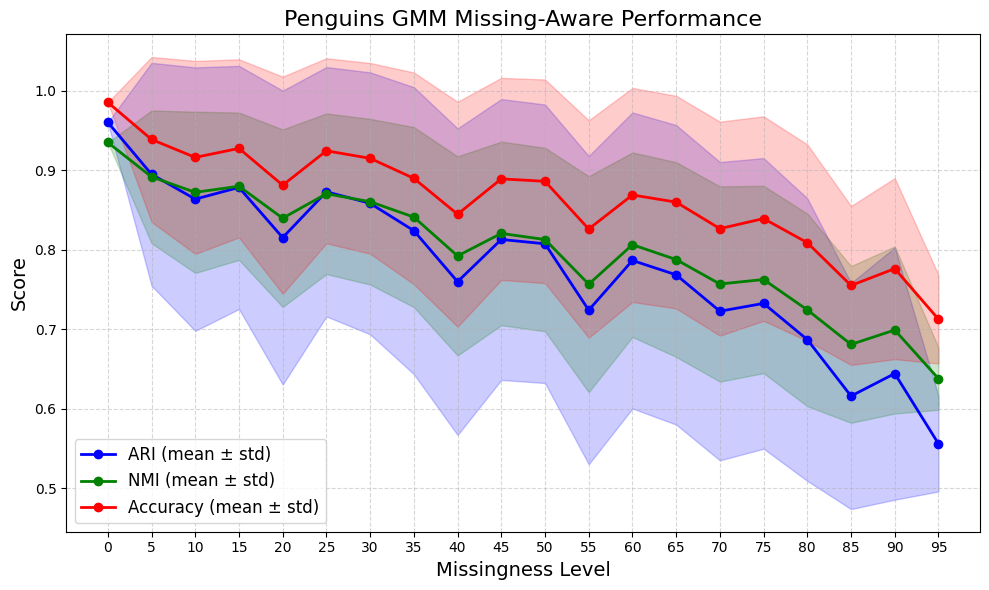

In [12]:
plot_dec_performance_average(
    missingness_percentages=missingness_percentages * 100,
    score_arrays=[ari_runs, nmi_runs, acc_runs],
    labels=['ARI', 'NMI', 'Accuracy'],
    title="Penguins GMM Missing-Aware Performance"
)

In [19]:
def run_simulation(frac_list, X, y, n_classes):
    run_ari, run_nmi, run_acc = [], [], []

    for frac in frac_list:
        missing_data = missingness.apply_stratified(
            X, y,
            method="mar",
            frac=frac,
            dep_col=0,
            miss_col=1,
        )

        x_filled = knn_imputer.impute(missing_data)

        gmm = GaussianMixture(n_components=n_classes)
        y_pred = gmm.fit_predict(x_filled)

        run_ari.append(adjusted_rand_score(y, y_pred))
        run_nmi.append(normalized_mutual_info_score(y, y_pred))
        run_acc.append(clustering_accuracy(y, y_pred))

    return run_ari, run_nmi, run_acc


results = Parallel(n_jobs=-1, backend="loky")(
    delayed(run_simulation)(missingness_percentages, X, y, n_classes)
    for _ in range(n_runs)
)

ari_runs = [r[0] for r in results]
nmi_runs = [r[1] for r in results]
acc_runs = [r[2] for r in results]

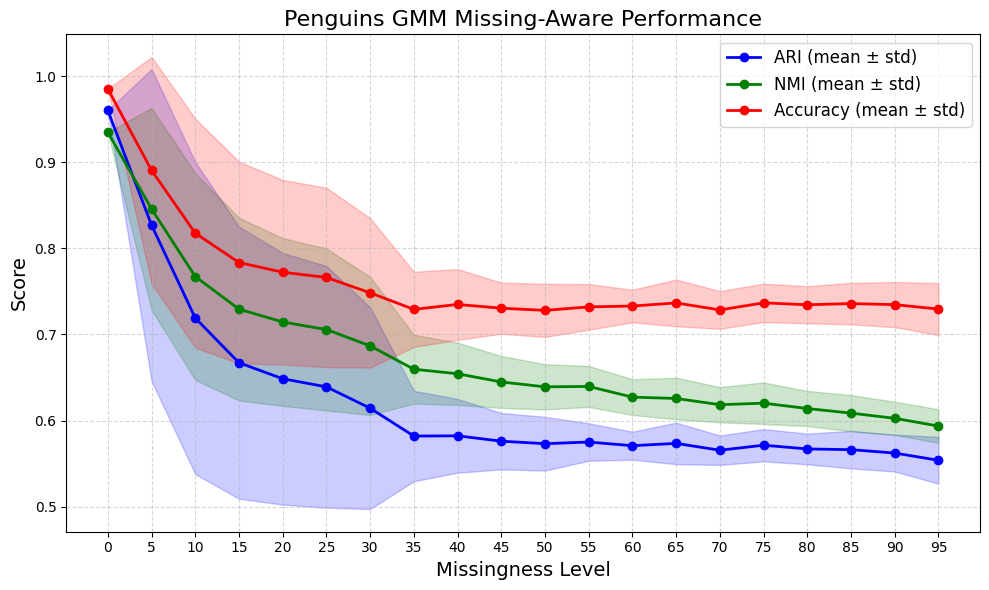

In [20]:
plot_dec_performance_average(
    missingness_percentages=missingness_percentages * 100,
    score_arrays=[ari_runs, nmi_runs, acc_runs],
    labels=['ARI', 'NMI', 'Accuracy'],
    title="Penguins GMM Missing-Aware Performance"
)